In [6]:
"""
Color Code Threshold Simulation with Tesseract Decoder
=======================================================

Full pipeline:
  1. Build superdense syndrome extraction circuits for triangular color code
     memory patches at multiple distances using color-code-stim.
  2. Run Monte Carlo simulations via Sinter + Tesseract decoder.
  3. Plot the logical error rate threshold.

Install dependencies first:
    pip install color-code-stim sinter tesseract-decoder matplotlib

Requirements:
    Python >= 3.11 (required by color-code-stim)
"""

# ──────────────────────────────────────────────────────────────────────────────
# STEP 0 — Imports
# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import sinter
import stim
from tesseract_decoder import make_tesseract_sinter_decoders_dict

#----------------------------------
def generate_color_code_stim_circuit(distance):
    if distance not in [3, 5, 7]:
        raise ValueError("Only distances 3, 5, 7 are supported.")
    
    lines = []
    lines.append(f"# Stim circuit for color code distance {distance}")
    
    # Define number of data qubits and stabilizers roughly
    if distance == 3:
        n_data = 7
        n_x_and = 3
        n_z_and = 3
        layers = 2
    elif distance == 5:
        n_data = 19
        n_x_and = 9
        n_z_and = 9
        layers = 4
    else:  # distance 7
        n_data = 37
        n_x_and = 15
        n_z_and = 15
        layers = 6

    # Define qubit names
    data_qubits = [f"d{i}" for i in range(n_data)]
    x_ancillas = [f"x_a{i}" for i in range(n_x_and)]
    z_ancillas = [f"z_a{i}" for i in range(n_z_and)]
    
    # X-stabilizer layers
    lines.append("\n# --- X-Stabilizer extraction ---")
    for layer in range(layers):
        lines.append(f"# Layer {layer+1}")
        for i in range(layer, n_x_and, layers):
            and = x_ancillas[i]  # ← hier definieren!
            q_indices = [2*i % n_data, (2*i+1) % n_data]
            for dq_idx in q_indices:
                lines.append(f"CX {and} {data_qubits[dq_idx]}")
    
    # Measure X ancillas
    for and in x_ancillas:
        lines.append(f"M X {and}")
    
    # Z-stabilizer layers
    lines.append("\n# --- Z-Stabilizer extraction ---")
    for layer in range(layers):
        lines.append(f"# Layer {layer+1}")
        for i in range(layer, n_z_and, layers):
            and = z_ancillas[i]  # ← hier definieren!
            q_indices = [2*i % n_data, (2*i+1) % n_data]
            for dq_idx in q_indices:
                lines.append(f"CX {data_qubits[dq_idx]} {and}")
    
    # Measure Z ancillas
    for and in z_ancillas:
        lines.append(f"M Z {and}")
    
    return "\n".join(lines)




#-------------------------------


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1 — Configuration: distances and physical error rates to sweep
# ──────────────────────────────────────────────────────────────────────────────

# Odd distances only — triangular patch requires odd d.
# Use d=3,5,7 for a quick run; add d=9,11 for a more convincing threshold plot
# (at the cost of longer runtime).
DISTANCES = [3, 5, 7]

# Physical error probabilities to sweep.
# Bracket the expected circuit-level threshold (~0.5–0.7% for color codes).
PHYSICAL_ERROR_RATES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.008, 0.010]

# Number of syndrome extraction rounds per circuit.
# Convention: use rounds = d for a fair comparison across distances.
ROUNDS_PER_DISTANCE = {d: d for d in DISTANCES}

# Sinter collection settings — adjust to taste.
# max_shots:  upper bound on total shots per task
# max_errors: stop early once this many logical errors are observed
# num_workers: parallel CPU workers (set to number of physical cores)
MAX_SHOTS  = 100_000
MAX_ERRORS = 500
NUM_WORKERS = 4


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2 — Build Sinter tasks
#           Each task = one (distance, physical_error_rate) combination.
#           color-code-stim constructs the superdense syndrome extraction
#           circuit; we extract the underlying stim.Circuit for Sinter.
# ──────────────────────────────────────────────────────────────────────────────

def build_tasks(distances, error_rates, rounds_per_distance):
    """Return a list of sinter.Task objects for the given sweep."""
    tasks = []
    for d in distances:
        rounds = rounds_per_distance[d]
        for p in error_rates:
            # --- Build circuit via color-code-stim ---
            # circuit_type="tri"  →  triangular memory patch (odd d only)
            # superdense_circuit=True  →  use the superdense syndrome
            #                             extraction schedule (fewer rounds
            #                             per logical cycle than space-mux)
            #noise = NoiseModel.uniform_circuit_noise(p)
            #cc = ColorCode(
            #    d=d,
            #    rounds=rounds,
            #    circuit_type="tri",
            #    noise_model=noise,
            #    superdense_circuit=True,   # ← superdense extraction
            #)

            # The underlying stim.Circuit lives on cc.simulator.circuit
            #stim_circuit = cc.simulator.circuit

            
            stim_circuit_text = generate_color_code_stim_circuit(d)
            stim_circuit = stim.Circuit(stim_circuit_text)

            tasks.append(
                sinter.Task(
                    circuit=stim_circuit,
                    # json_metadata is passed through to the stats objects and
                    # used later when plotting.
                    json_metadata={
                        "d": d,
                        "p": p,
                        "rounds": rounds,
                    },
                )
            )
    print(f"Built {len(tasks)} tasks "
          f"({len(distances)} distances × {len(error_rates)} error rates).")
    return tasks


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3 — Run simulations with Sinter + Tesseract
#
# make_tesseract_sinter_decoders_dict() returns a dict with three pre-tuned
# decoder presets from the Tesseract paper:
#   'tesseract'             — balanced defaults
#   'tesseract-short-beam'  — faster, slightly lower accuracy
#   'tesseract-long-beam'   — slower, higher accuracy
#
# We use 'tesseract' here. Switch to 'tesseract-long-beam' for publication
# quality results.
# ──────────────────────────────────────────────────────────────────────────────

def run_simulations(tasks):
    """Collect statistics using Sinter + Tesseract."""
    decoder_name = "tesseract"
    decoder_dict = make_tesseract_sinter_decoders_dict()

    print(f"\nRunning simulations with decoder '{decoder_name}' ...")
    print(f"  max_shots={MAX_SHOTS}, max_errors={MAX_ERRORS}, "
          f"num_workers={NUM_WORKERS}\n")

    stats = sinter.collect(
        tasks=tasks,
        decoders=[decoder_name],
        custom_decoders=decoder_dict,
        num_workers=NUM_WORKERS,
        max_shots=MAX_SHOTS,
        max_errors=MAX_ERRORS,
        print_progress=True,   # live progress bar in the terminal
    )
    return stats, decoder_name


# ──────────────────────────────────────────────────────────────────────────────
# STEP 4 — Plot threshold
#
# sinter.plot_error_rate handles error bars and curve grouping automatically.
# The x-axis is physical error rate; each curve is one code distance.
# The threshold is the crossing point of curves for different distances.
# ──────────────────────────────────────────────────────────────────────────────

def plot_threshold(stats, decoder_name, save_path="threshold_plot.pdf"):
    """Plot logical error rate vs physical error rate for each distance."""
    fig, ax = plt.subplots(figsize=(7, 5))

    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        # x-axis: physical error rate stored in metadata
        x_func=lambda stat: stat.json_metadata["p"],
        # one curve per code distance
        group_func=lambda stat: f"d = {stat.json_metadata['d']}",
        # optional: add dashed linear fit in log-log space to guide the eye
        # line_fits=("log", "log"),
    )

    ax.set_xlabel("Physical error rate $p$", fontsize=13)
    ax.set_ylabel("Logical error rate $p_L$", fontsize=13)
    ax.set_title(
        f"2D Color Code — Triangular Patch\n"
        f"Superdense extraction, Tesseract decoder ({decoder_name})",
        fontsize=12,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=11)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

    # Add a vertical dashed line at the approximate known threshold (~0.55%)
    # as a visual reference.  Remove if you prefer a clean plot.
    ax.axvline(
        x=0.0055,
        color="gray",
        linestyle=":",
        linewidth=1.2,
        label="Approx. threshold (~0.55%)",
    )
    ax.legend(fontsize=10)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    print(f"\nThreshold plot saved to: {save_path}")
    plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Step 1 & 2: build tasks
    tasks = build_tasks(DISTANCES, PHYSICAL_ERROR_RATES, ROUNDS_PER_DISTANCE)

    # Step 3: simulate
    stats, decoder_name = run_simulations(tasks)

    # Step 4: plot
    plot_threshold(stats, decoder_name, save_path="threshold_plot.pdf")

    # Optional: also print a raw CSV summary
    print("\n--- Raw statistics (CSV) ---")
    print(sinter.CSV_HEADER)
    for s in sorted(stats, key=lambda x: (x.json_metadata["d"],
                                           x.json_metadata["p"])):
        print(s.to_csv_line())

ValueError: Expected a digit but got '_'

Starting 4 workers...


Built 12 tasks (3 distances × 4 error rates).


12 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
        1 pymatching 34m      99999         500 d=3,p=0.001,rounds=3
        1 pymatching   ?     100000         500 d=3,p=0.002,rounds=3
        1 pymatching   ?     100000         500 d=3,p=0.004,rounds=3
        1 pymatching   ?     100000         500 d=3,p=0.008,rounds=3
        0 pymatching ?·∞     100000         500 d=5,p=0.001,rounds=5
        0 pymatching ?·∞     100000         500 d=5,p=0.002,rounds=5
        0 pymatching ?·∞     100000         500 d=5,p=0.004,rounds=5
        0 pymatching ?·∞     100000         500 d=5,p=0.008,rounds=5
        0 pymatching ?·∞     100000         500 d=7,p=0.001,rounds=7
        0 pymatching ?·∞     100000         500 d=7,p=0.002,rounds=7
        0 pymatching ?·∞     100000         500 d=7,p=0.004,rounds=7
        0 pymatching ?·∞     100000         500 d=7,p=0.008,rounds=7
8 tasks left:
  workers    decoder eta shots_left errors_left json_metadata       
     

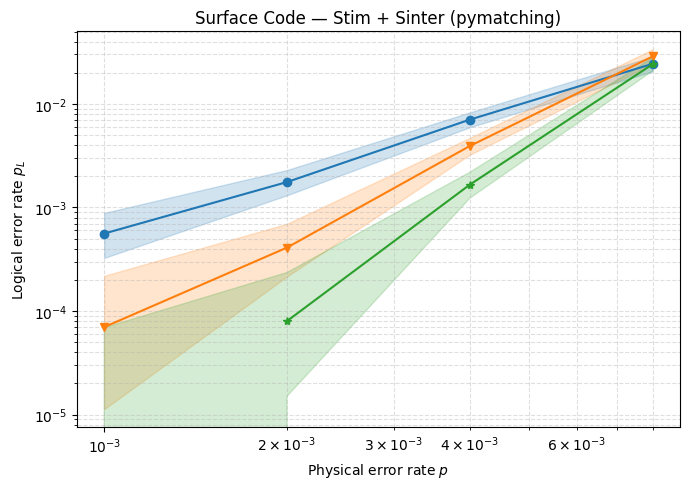

In [12]:
import stim
import sinter
import matplotlib.pyplot as plt

# ---------------------------
# 1. Surface Code Configuration
# ---------------------------
DISTANCES = [3, 5, 7]          # Code-Distanzen
PHYSICAL_ERROR_RATES = [0.001, 0.002, 0.004, 0.008]  # Fehlerwahrscheinlichkeiten
ROUNDS_PER_DISTANCE = {d: d for d in DISTANCES}       # convention: rounds = distance

# ---------------------------
# 2. Automatisch Surface-Code-Stim Circuits bauen
# ---------------------------
def build_surface_code_tasks(distances, error_rates, rounds_per_distance):
    tasks = []
    for d in distances:
        rounds = rounds_per_distance[d]
        for p in error_rates:
            # stim erzeugt automatisch einen planar surface code circuit
            # mit superdense syndrome extraction (default)
            circuit = stim.Circuit.generated(
                "surface_code:rotated_memory_z",  # ← prefix "surface_code:" zwingend
                distance=d,
                rounds=rounds,
                after_clifford_depolarization=p,
                before_round_data_depolarization=0.0,
                before_measure_flip_probability=p,
                after_reset_flip_probability=p
            )

            tasks.append(
                sinter.Task(
                    circuit=circuit,
                    json_metadata={"d": d, "p": p, "rounds": rounds},
                )
            )
    print(f"Built {len(tasks)} tasks ({len(distances)} distances × {len(error_rates)} error rates).")
    return tasks

# ---------------------------
# 3. Simulation mit Sinter
# ---------------------------
def run_surface_code_simulation(tasks):
    decoder_name = "pymatching"  # stim + sinter kann pymatching oder tesseract nutzen
    stats = sinter.collect(
        tasks=tasks,
        decoders=[decoder_name],
        num_workers=4,
        max_shots=100_000,
        max_errors=500,
        print_progress=True,
    )
    return stats, decoder_name

# ---------------------------
# 4. Threshold Plot
# ---------------------------
def plot_threshold(stats, decoder_name, save_path="threshold_plot_surface.pdf"):
    fig, ax = plt.subplots(figsize=(7,5))
    sinter.plot_error_rate(
        ax=ax,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["p"],
        group_func=lambda stat: f"d = {stat.json_metadata['d']}",
    )
    ax.set_xlabel("Physical error rate $p$")
    ax.set_ylabel("Logical error rate $p_L$")
    ax.set_title(f"Surface Code — Stim + Sinter ({decoder_name})")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()

# ---------------------------
# 5. Main
# ---------------------------
if __name__ == "__main__":
    tasks = build_surface_code_tasks(DISTANCES, PHYSICAL_ERROR_RATES, ROUNDS_PER_DISTANCE)
    stats, decoder_name = run_surface_code_simulation(tasks)
    plot_threshold(stats, decoder_name)

## from getting started notebook in stim

In [3]:
import os
import matplotlib.pyplot as plt
import sinter
import stim

surface_code_tasks = [
    sinter.Task(
        circuit = stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
        ),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in [0.008, 0.009, 0.01, 0.011, 0.012]
]

collected_surface_code_stats: list[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

Starting 16 workers...
15 tasks left:
  workers    decoder  eta shots_left errors_left json_metadata   
        1 pymatching    ?    1000000        5000 d=3,r=9,p=0.008 
        1 pymatching    ?    1000000        5000 d=3,r=9,p=0.009 
        1 pymatching    ?    1000000        5000 d=3,r=9,p=0.01  
        1 pymatching    ?    1000000        5000 d=3,r=9,p=0.011 
        1 pymatching 196m     999999        5000 d=3,r=9,p=0.012 
        1 pymatching    ?    1000000        5000 d=5,r=15,p=0.008
        1 pymatching    ?    1000000        5000 d=5,r=15,p=0.009
        1 pymatching    ?    1000000        5000 d=5,r=15,p=0.01 
        1 pymatching    ?    1000000        5000 d=5,r=15,p=0.011
        1 pymatching    ?    1000000        5000 d=5,r=15,p=0.012
        1 pymatching    ?    1000000        5000 d=7,r=21,p=0.008
        1 pymatching    ?    1000000        5000 d=7,r=21,p=0.009
        1 pymatching    ?    1000000        5000 d=7,r=21,p=0.01 
        1 pymatching    ?    1000000  

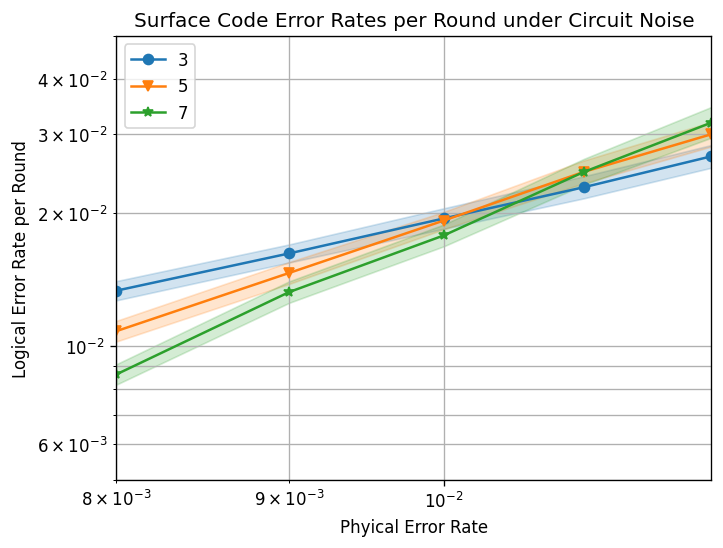

In [4]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
    failure_units_per_shot_func=lambda stat: stat.json_metadata['r'],
)
ax.set_ylim(5e-3, 5e-2)
ax.set_xlim(0.008, 0.012)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)

In [18]:
import os
import matplotlib.pyplot as plt
import sinter
import stim
import tesseract_decoder

decoder_name = "tesseract"
decoder_dict = tesseract_decoder.make_tesseract_sinter_decoders_dict()

surface_code_tasks = [
    sinter.Task(
        circuit = stim.Circuit.generated(
            "color_code:memory_xyz",
            rounds=d * 3,
            distance=d,
            after_clifford_depolarization=noise,
            after_reset_flip_probability=noise,
            before_measure_flip_probability=noise,
            before_round_data_depolarization=noise,
        ),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in [0.1,0.2]#[0.008, 0.009, 0.01, 0.011, 0.012]
]

collected_surface_code_stats: list[sinter.TaskStats] = sinter.collect(
    num_workers=2,#os.cpu_count(),
    tasks=surface_code_tasks,
    custom_decoders=decoder_dict,
    decoders=[decoder_name],
    max_shots=100,
    max_errors=50,
    print_progress=True,
)

Starting 2 workers...
6 tasks left:
  workers   decoder eta shots_left errors_left json_metadata 
        1 tesseract   ?        100          50 d=3,r=9,p=0.1 
        1 tesseract <1m         99          50 d=3,r=9,p=0.2 
        0 tesseract ?·∞        100          50 d=5,r=15,p=0.1
        0 tesseract ?·∞        100          50 d=5,r=15,p=0.2
        0 tesseract ?·∞        100          50 d=7,r=21,p=0.1
        0 tesseract ?·∞        100          50 d=7,r=21,p=0.2
6 tasks left:
  workers   decoder eta shots_left errors_left json_metadata 
        1 tesseract <1m         99          50 d=3,r=9,p=0.1 
        1 tesseract <1m         99          50 d=3,r=9,p=0.2 
        0 tesseract ?·∞        100          50 d=5,r=15,p=0.1
        0 tesseract ?·∞        100          50 d=5,r=15,p=0.2
        0 tesseract ?·∞        100          50 d=7,r=21,p=0.1
        0 tesseract ?·∞        100          50 d=7,r=21,p=0.2
6 tasks left:
  workers   decoder eta shots_left errors_left json_metadata 
      

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
    failure_units_per_shot_func=lambda stat: stat.json_metadata['r'],
)
ax.set_ylim(5e-3, 5e-2)
ax.set_xlim(0.008, 0.012)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)

In [16]:
d = 3
noise = 0.01

circuit = stim.Circuit.generated(
    "color_code:memory_xyz",
    rounds=2,
    distance=d,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
),

print(circuit[0].to_crumble_url())


https://algassert.com/crumble#circuit=Q(0,0)0;Q(1,0)1;Q(2,0)2;Q(3,0)3;Q(0.5,1)4;Q(1.5,1)5;Q(2.5,1)6;Q(1,2)7;Q(2,2)8;Q(1.5,3)9;R_0_1_2_3_4_5_6_7_8_9;X_ERROR(0.01)0_1_2_3_4_5_6_7_8_9;REPEAT_2_{;TICK;DEPOLARIZE1(0.01)0_1_3_5_6_7_9;C_XYZ_0_1_3_5_6_7_9;DEPOLARIZE1(0.01)0_1_3_5_6_7_9;TICK;CX_5_4_3_2;DEPOLARIZE2(0.01)5_4_3_2;TICK;CX_7_4_6_2;DEPOLARIZE2(0.01)7_4_6_2;TICK;CX_1_4_6_8;DEPOLARIZE2(0.01)1_4_6_8;TICK;CX_1_2_7_8;DEPOLARIZE2(0.01)1_2_7_8;TICK;CX_5_2_9_8;DEPOLARIZE2(0.01)5_2_9_8;TICK;CX_0_4_5_8;DEPOLARIZE2(0.01)0_4_5_8;TICK;X_ERROR(0.01)2_4_8;MR_2_4_8;X_ERROR(0.01)2_4_8;};DT(2,0,0)rec[-3]_rec[-6];DT(0.5,1,0)rec[-2]_rec[-5];DT(2,2,0)rec[-1]_rec[-4];X_ERROR(0.01)0_1_3_5_6_7_9;MY_0_1_3_5_6_7_9;DT(2,0,1)rec[-3]_rec[-4]_rec[-5]_rec[-6]_rec[-10]_rec[-13];DT(0.5,1,1)rec[-2]_rec[-4]_rec[-6]_rec[-7]_rec[-9]_rec[-12];DT(2,2,1)rec[-1]_rec[-2]_rec[-3]_rec[-4]_rec[-8]_rec[-11];OI(0)rec[-5]_rec[-6]_rec[-7]_


In [20]:
print(circuit[0])

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 0) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(0.5, 1) 4
QUBIT_COORDS(1.5, 1) 5
QUBIT_COORDS(2.5, 1) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(2, 2) 8
QUBIT_COORDS(1.5, 3) 9
R 0 1 2 3 4 5 6 7 8 9
X_ERROR(0.01) 0 1 2 3 4 5 6 7 8 9
REPEAT 2 {
    TICK
    DEPOLARIZE1(0.01) 0 1 3 5 6 7 9
    C_XYZ 0 1 3 5 6 7 9
    DEPOLARIZE1(0.01) 0 1 3 5 6 7 9
    TICK
    CX 5 4 3 2
    DEPOLARIZE2(0.01) 5 4 3 2
    TICK
    CX 7 4 6 2
    DEPOLARIZE2(0.01) 7 4 6 2
    TICK
    CX 1 4 6 8
    DEPOLARIZE2(0.01) 1 4 6 8
    TICK
    CX 1 2 7 8
    DEPOLARIZE2(0.01) 1 2 7 8
    TICK
    CX 5 2 9 8
    DEPOLARIZE2(0.01) 5 2 9 8
    TICK
    CX 0 4 5 8
    DEPOLARIZE2(0.01) 0 4 5 8
    TICK
    X_ERROR(0.01) 2 4 8
    MR 2 4 8
    X_ERROR(0.01) 2 4 8
}
DETECTOR(2, 0, 0) rec[-3] rec[-6]
DETECTOR(0.5, 1, 0) rec[-2] rec[-5]
DETECTOR(2, 2, 0) rec[-1] rec[-4]
X_ERROR(0.01) 0 1 3 5 6 7 9
MY 0 1 3 5 6 7 9
DETECTOR(2, 0, 1) rec[-3] rec[-4] rec[-5] rec[-6] rec[-10] rec[-1

In [21]:
from tqec.gallery import cnot

graph = cnot()

from tqec import Basis, NoiseModel, compile_block_graph

graph = cnot(Basis.X)
compiled_graph = compile_block_graph(graph)
circuit = compiled_graph.generate_stim_circuit(
    k=1, noise_model=NoiseModel.uniform_depolarizing(p=0.001)
)

In [ ]:
circuit.diagram('timeline-svg')


In [33]:
from tqec import compile_block_graph


correlation_surfaces = graph.find_correlation_surfaces()
compiled_computation = compile_block_graph(graph, observables=[correlation_surfaces[1]])

from multiprocessing import cpu_count
import numpy as np
from pathlib import Path

from tqec import NoiseModel
from tqec.simulation.simulation import start_simulation_using_sinter


# returns a iterator
stats = start_simulation_using_sinter(
    graph,
    ks=range(1, 4),  # k values for the code distance
    ps=list(np.logspace(-4, -1, 10)),  # error rates
    noise_model_factory=NoiseModel.uniform_depolarizing,  # noise model
    manhattan_radius=2,  # parameter for automatic detector computation
    observables=[correlation_surfaces[1]],  # observable of interest
    decoders=["pymatching"],
    num_workers=cpu_count(),
    max_shots=10_000_000,
    max_errors=500,
    save_resume_filepath=Path("./_examples_database/quick_start.csv"),
    database_path=Path("./_examples_database/database.pkl"),
)

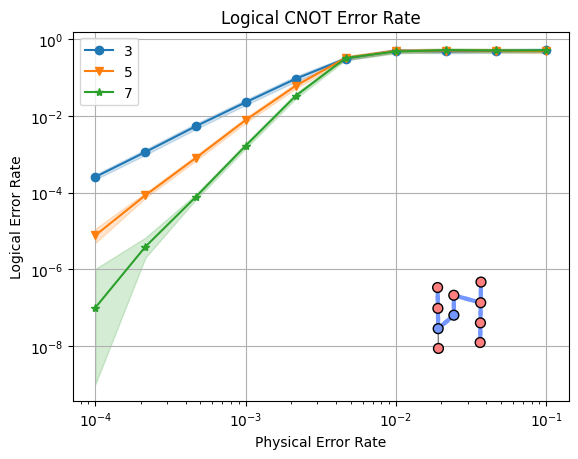

In [34]:
import matplotlib.pyplot as plt
import sinter

from tqec.simulation.plotting.inset import plot_observable_as_inset

zx_graph = graph.to_zx_graph()

fig, ax = plt.subplots()
# len(stats) = 1 if we have multiple we can iterate over the results
sinter.plot_error_rate(
    ax=ax,
    stats=next(iter(stats)),
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["d"],
)
plot_observable_as_inset(ax, zx_graph, correlation_surfaces[1])
ax.grid(axis="both")
ax.legend()
ax.loglog()
ax.set_title("Logical CNOT Error Rate")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate")
plt.show()